# Estudo de Caso 1: Análise de Inquéritos Policiais em Goiás

## Introdução

Este estudo de caso explora dados amostrais sobre inquéritos policiais em 6 Comarcas do Estado de Goiás. O objetivo é aprender a criar e interpretar diferentes tipos de gráficos estatísticos para Análise Exploratória de Dados.

### Objetivos de Aprendizagem

Ao final deste estudo de caso, você será capaz de:
1. Criar gráficos de barras/colunas para variáveis categóricas
2. Criar dot plots, histogramas e boxplots para variáveis quantitativas
3. Comparar distribuições de variáveis quantitativas entre categorias/classes de uma variável categórica
4. Analisar associações entre variáveis categóricas usando gráficos mosaico (quiçá *Correspondence Analysis Plot*)
5. Explorar relações entre variáveis quantitativas usando diagramas de dispersão e retas de regressão

---

## 1. Tipos de Gráficos: Uma Introdução Visual

Antes de trabalhar com os dados, vamos entender os principais tipos de gráficos que utilizaremos.

### 1.1 Gráficos de Barras/Colunas

**Quando usar:** Para representar a distribuição de variáveis **categóricas** (nominais ou ordinais).

**Como interpretar:**
- Cada barra representa uma categoria
- A altura da barra mostra a frequência (contagem) ou proporção
- Facilita a comparação entre categorias
- Identifica a categoria mais/menos frequente

**Exemplo:** Distribuição de casos por comarca, tipo de crime, etc.

### 1.2 Dot Plot (Gráfico de Pontos)

**Quando usar:** Para variáveis **quantitativas**, especialmente com amostras pequenas ou médias.

**Como interpretar:**
- Cada ponto representa uma observação
- Mostra a distribuição real dos dados sem agrupamento
- Permite identificar valores repetidos (pontos empilhados)
- Facilita a identificação de outliers (valores atípicos)
- Mostra claramente lacunas nos dados

**Exemplo:** Duração de inquéritos em dias, número de testemunhas, etc.

### 1.3 Histograma

**Quando usar:** Para variáveis **quantitativas**, especialmente com amostras grandes.

**Como interpretar:**
- O eixo horizontal é dividido em intervalos (bins)
- A altura de cada barra mostra quantas observações estão naquele intervalo
- Permite visualizar:
  - **Forma da distribuição:** simétrica, assimétrica (skewed)
  - **Centro:** onde está a maioria dos dados
  - **Dispersão:** quão espalhados estão os dados
  - **Outliers:** valores muito distantes da maioria
  - **Multimodalidade:** presença de múltiplos picos

**Dica:** O número de intervalos pode mudar a interpretação. Experimente diferentes valores!

### 1.4 Boxplot (Diagrama de Caixa)

**Quando usar:** Para variáveis **quantitativas**, especialmente para comparar grupos.

**Como interpretar:**
- **Linha central da caixa:** mediana (Q2) - valor que divide os dados ao meio
- **Limites da caixa:** 
  - Inferior: primeiro quartil (Q1) - 25% dos dados estão abaixo
  - Superior: terceiro quartil (Q3) - 75% dos dados estão abaixo
- **Altura da caixa (IQR):** amplitude interquartílica = Q3 - Q1 (mostra a dispersão dos 50% centrais)
- **Linhas (whiskers):** geralmente se estendem até 1.5 × IQR
- **Pontos fora das linhas:** possíveis outliers

**Vantagens:**
- Resumo visual dos 5 números (mínimo, Q1, Q2, Q3, máximo)
- Excelente para comparar múltiplos grupos lado a lado
- Identifica outliers claramente
- Mostra assimetria na distribuição

### 1.5 Gráfico Mosaico

**Quando usar:** Para explorar a relação entre duas ou mais variáveis **categóricas**.

**Como interpretar:**
- Cada retângulo representa uma combinação de categorias
- A **área** do retângulo é proporcional à frequência da combinação
- A **largura** representa a proporção da primeira variável
- A **altura** dentro de cada coluna representa a distribuição condicional da segunda variável
- Facilita identificar:
  - **Associações:** padrões diferentes do esperado se as variáveis fossem independentes
  - **Proporções condicionais:** como uma variável se distribui dentro de cada categoria da outra

**Exemplo:** Relação entre comarca e resultado do inquérito

### 1.6 Diagrama de Dispersão (Scatter Plot)

**Quando usar:** Para explorar a relação entre duas variáveis **quantitativas**.

**Como interpretar:**
- Cada ponto representa uma observação com seus valores em X e Y
- **Direção da relação:**
  - Positiva: pontos sobem da esquerda para direita
  - Negativa: pontos descem da esquerda para direita
  - Sem relação: pontos espalhados aleatoriamente
- **Força da relação:** quão próximos os pontos estão de um padrão linear
- **Forma:** linear, curvilínea, ou sem padrão claro
- **Reta de regressão (mínimos quadrados):** mostra a tendência linear média
- **Outliers:** pontos muito distantes do padrão geral

**Exemplo:** Relação entre duração do inquérito e número de diligências

---

## 2. Preparação do Ambiente

Vamos carregar as bibliotecas necessárias para nossa análise.

In [28]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Bibliotecas carregadas com sucesso!")

✓ Bibliotecas carregadas com sucesso!


## 3. Carregamento e Exploração Inicial dos Dados

In [29]:
# Carregar o dicionário de variáveis
dicionario = pd.read_excel('dat/estcaso_ip/ApendiceA-QuadroVariaveis.xlsx')
print("=" * 80)
print("DICIONÁRIO DE VARIÁVEIS")
print("=" * 80)
display(dicionario)

DICIONÁRIO DE VARIÁVEIS


,N.,Categoria,Variável,Descrição,Tipo,Método de coleta
0,1,1 - Identificação,N_ordem,Número sequencial que identifica cada procedim...,Numérico,Registro automatizado na tabela.
1,2,1 - Identificação,Link_atena,Link de acesso ao procedimento no sistema de g...,Qualitativa nominal,Extração do sistema Atena do MPGO.
2,3,1 - Identificação,N_atena,Número de identificação único atribuído a cada...,Numérico,Extração do sistema Atena do MPGO.
3,4,1 - Identificação,Promotoria,Nome da promotoria de justiça responsável pelo...,Qualitativa nominal,Extração do sistema Atena do MPGO.
4,5,1 - Identificação,Comarca,Nome da comarca relacionada à promotoria de ju...,Qualitativa nominal,Extração do sistema Atena do MPGO.
5,6,1 - Identificação,N_projudi,Número de identificação único atribuído a cada...,Numérico,Extração do sistema Projudi do TJGO.
6,7,1 - Identificação,Nome_delegacia,Nome da delegacia de polícia responsável pela ...,Qualitativa nominal,Extração do sistema Projudi do TJGO.
7,8,1 - Identificação,N_ip_ou_apf,Número do inquérito policial ou do auto de pri...,Qualitativa nominal,Extração do sistema Projudi do TJGO.
8,9,1 - Identificação,N_aleatorio,Número de sorteio aleatório utilizado para a s...,Numérico,Gerado no aplicativo Microsoft Excel
9,10,1 - Identificação,Selecionado,Identificação de procedimento selecionado para...,Qualitativa nominal,Registrado manualmente na tabela


In [30]:
# Carregar a base de dados
dados = pd.read_excel('dat/estcaso_ip/ApendiceB-BaseDados.xlsx')

print("=" * 80)
print("VISÃO GERAL DOS DADOS")
print("=" * 80)
print(f"\nDimensões: {dados.shape[0]} observações × {dados.shape[1]} variáveis\n")

print("Primeiras linhas:")
display(dados.head(10))

print("\nInformações sobre as variáveis:")
dados.info()

print("\nEstatísticas descritivas:")
display(dados.describe(include='all'))

VISÃO GERAL DOS DADOS

Dimensões: 218 observações × 28 variáveis

Primeiras linhas:


,N_ordem,Comarca,Assunto_resumido,Status_projudi,Data_prescricao_projudi,N_indiciados,N_vitimas,Reu_preso,Tramitacao_direta,1_data_fato,...,Nome_lei,Capitulacao,Arma_de_fogo,Validacao,Prazo_conclusao_IP,Tempo_conclusao_ip,Quantidade_manifestacao_ip,Tipo_manifestacao_mp,Tempo_entre_manifestacoes_mp,Tempo_conclusao_mp
0,1,GOIANIA,Homicídio Simples,Arquivado - DEFERIMENTO DO PEDIDO,2035-12-17 00:00:00,0,2,0,1,2015-12-17 00:00:00,...,Código Penal,CPB ART. 121 C/C ART. 18 INC. I: HOMICÍDIO DOLOSO,1,1,30,3021,0,Não se aplica,Prejudicado,7
1,2,APARECIDA DE GOIANIA,Homicídio Simples,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA ...,2042-08-29 00:00:00,0,1,0,1,2022-08-03 00:00:00,...,Código Penal,"ART. 121, CAPUT DO CPA HOMICIDIO SIMPLES COHSU...",1,1,30,596,4,DILAÇÃO DE PRAZO; CONFECÇÃO DO RELATÓRIO FINAL...,304,494
2,3,APARECIDA DE GOIANIA,Homicídio Simples,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA ...,2039-01-06 00:00:00,0,1,0,1,2019-01-07 00:00:00,...,Código Penal,ARTIGO(S) l2l do CP,1,1,30,1471,1,DILAÇÃO DE PRAZO;,0,329
3,4,GOIANIA,Homicídio Simples,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA ...,2042-03-08 00:00:00,1,1,0,0,2014-09-06 00:00:00,...,Código Penal,"Artigo: 121, DO CPB",1,1,30,2863,14,DILAÇÃO DE PRAZO; oficio à Corregedoria da Pol...,1133,1220
4,5,SENADOR CANEDO,Homicídio Simples,Arquivado - LITISPENDÊNCIA,Não informada,1,1,0,0,2022-09-11 00:00:00,...,Código Penal,ART. 121. §2°. INC. II DO CPB HОMІСÍDIO QUALIF...,0,1,30,14,1,RELATÓRIO MÉDICO DA VÍTIMA,0,81
5,6,GOIANIA,Homicídio Qualificado,Ativo,2037-04-08 00:00:00,0,1,0,0,2017-04-08 00:00:00,...,Código Penal,"ARTIGO 121, § 2º, INCISO IV DO CÓDIGO PENAL BR...",1,1,30,1789,13,CONCLUSÃO DO INQUÉRITO POLICIAL; DILAÇÃO DE PR...,1429,0
6,7,GOIANIA,Homicídio Simples,Ativo,2040-05-05 00:00:00,0,1,0,1,2020-05-05 00:00:00,...,Código Penal,"ARTIGO(S) 121, DO CPB",1,1,30,1230,10,HISTÓRICO CRIMINAL DA VÍTIMA; CONFIRMAÇÃO SOBR...,757,0
7,8,GOIANIA,Homicídio Simples,Arquivado - EXTINÇÃO DA PUNIBILIDADE-RENUNCIA ...,2044-12-10 00:00:00,1,1,1,0,2024-12-10 00:00:00,...,Código Penal,ART. 121 CAPUT DO CPB HOMICÍDIO SIMPLES TENTADO,0,1,10,73,12,CONCLUSÃO DAS INVESTIGAÇÕES; OITIVA DA VÍTIMA;...,300,302
8,9,APARECIDA DE GOIANIA,Homicídio Qualificado,Ativo,2041-02-04 00:00:00,0,1,0,1,2021-02-05 00:00:00,...,Código Penal,ARTIGO(S) Art' 121 do CPB,1,1,30,1403,1,DILAÇÃO DE PRAZO;,297,0
9,11,GOIANIA,Homicídio Simples,Arquivado - NÃO CONSTITUI CRIME (ATIPICIDADE),Não informada,0,1,0,0,2021-10-30 00:00:00,...,Código Penal,Art. 121 Caput do CPB Homicídio simples,1,1,30,85,3,Ofício à Corregedoria da Polícia Militar do Es...,95,132



Informações sobre as variáveis:
<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   N_ordem                       218 non-null    int64         
 1   Comarca                       218 non-null    str           
 2   Assunto_resumido              218 non-null    str           
 3   Status_projudi                218 non-null    str           
 4   Data_prescricao_projudi       218 non-null    object        
 5   N_indiciados                  218 non-null    int64         
 6   N_vitimas                     218 non-null    int64         
 7   Reu_preso                     218 non-null    int64         
 8   Tramitacao_direta             218 non-null    int64         
 9   1_data_fato                   218 non-null    object        
 10  2_data_instauracao            218 non-null    datetime64[us]
 11  3_data_rec

,N_ordem,Comarca,Assunto_resumido,Status_projudi,Data_prescricao_projudi,N_indiciados,N_vitimas,Reu_preso,Tramitacao_direta,1_data_fato,...,Nome_lei,Capitulacao,Arma_de_fogo,Validacao,Prazo_conclusao_IP,Tempo_conclusao_ip,Quantidade_manifestacao_ip,Tipo_manifestacao_mp,Tempo_entre_manifestacoes_mp,Tempo_conclusao_mp
count,218.000000,218,218,218,218,218.000000,218.000000,218.000000,218.000000,218,...,218,218,218.000000,218.0,218.000000,218.000000,218.000000,218,218,218.000000
unique,NaN,6,7,15,141,NaN,NaN,NaN,NaN,211,...,4,82,NaN,NaN,NaN,NaN,NaN,127,82,NaN
top,NaN,GOIANIA,Homicídio Simples,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA ...,Não informada,NaN,NaN,NaN,NaN,2019-08-30 00:00:00,...,Código Penal,Art. 121 do CPB,NaN,NaN,NaN,NaN,NaN,Não se aplica,Prejudicado,NaN
freq,NaN,101,171,90,71,NaN,NaN,NaN,NaN,2,...,215,78,NaN,NaN,NaN,NaN,NaN,83,95,NaN
mean,130.931193,NaN,NaN,NaN,NaN,0.665138,1.142202,0.096330,0.651376,NaN,...,NaN,NaN,0.697248,1.0,28.073394,1623.321101,2.775229,NaN,NaN,184.110092
min,1.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,NaN,...,NaN,NaN,0.000000,1.0,10.000000,0.000000,0.000000,NaN,NaN,0.000000
25%,66.250000,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,NaN,...,NaN,NaN,0.000000,1.0,30.000000,167.250000,0.000000,NaN,NaN,4.000000
50%,125.500000,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,1.000000,NaN,...,NaN,NaN,1.000000,1.0,30.000000,1107.500000,1.000000,NaN,NaN,50.500000
75%,188.750000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,1.000000,NaN,...,NaN,NaN,1.000000,1.0,30.000000,2523.750000,4.000000,NaN,NaN,232.000000
max,335.000000,NaN,NaN,NaN,NaN,5.000000,7.000000,1.000000,1.000000,NaN,...,NaN,NaN,1.000000,1.0,30.000000,8914.000000,17.000000,NaN,NaN,1335.000000


### 3.1 Converter variáveis com datas em datetime

In [31]:
# Padronizar valores textuais e converter colunas object para datetime
valores_invalidos = ['Não informada', 'Nao_houve', 'Nao_concluido']

# Identificar colunas do tipo object
# Mas  apenas colunas do tipo object e filtrar pelos nomes
# que contenham a substring data 
# (sem diferenciar maiúsculas/minúsculas).
colunas_object = [
col for col in dados.select_dtypes(include=['object']).columns
if 'data' in col.lower()
]

# Substituir valores inválidos por NA e converter para datetime
for col in colunas_object:
    dados[col] = dados[col].replace(valores_invalidos, pd.NA)
    dados[col] = pd.to_datetime(dados[col], errors='coerce')

print(f'Conversão concluída em {len(colunas_object)} colunas object.')
print('Campos inválidos foram substituídos por NA e datas inválidas por NaT.')

print("\nInformações sobre as variáveis:")
dados.info()

Conversão concluída em 5 colunas object.
Campos inválidos foram substituídos por NA e datas inválidas por NaT.

Informações sobre as variáveis:
<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   N_ordem                       218 non-null    int64         
 1   Comarca                       218 non-null    str           
 2   Assunto_resumido              218 non-null    str           
 3   Status_projudi                218 non-null    str           
 4   Data_prescricao_projudi       145 non-null    datetime64[us]
 5   N_indiciados                  218 non-null    int64         
 6   N_vitimas                     218 non-null    int64         
 7   Reu_preso                     218 non-null    int64         
 8   Tramitacao_direta             218 non-null    int64         
 9   1_data_fato                   2

### 3.2 Transformar Reu_preso em categórica binária

In [32]:
# Transformar Reu_preso em categórica binária
# A variável Reu_preso é int64 com valores 0 e 1
# 0 = não (réu não estava preso)
# 1 = sim (réu estava preso)

# Verificar valores únicos antes da transformação
print("Valores únicos em Reu_preso:")
print(dados['Reu_preso'].value_counts())
print(f"Tipo atual: {dados['Reu_preso'].dtype}")

# Criar mapeamento de numérico para categórico
mapeamento = {0: 'não', 1: 'sim'}

# Aplicar transformação para categórica
dados['Reu_preso'] = dados['Reu_preso'].map(mapeamento).astype('category')

# Verificar resultado
print("\nApós transformação:")
print(dados['Reu_preso'].value_counts())
print(f"Tipo da variável: {dados['Reu_preso'].dtype}")

Valores únicos em Reu_preso:
Reu_preso
0    197
1     21
Name: count, dtype: int64
Tipo atual: int64

Após transformação:
Reu_preso
não    197
sim     21
Name: count, dtype: int64
Tipo da variável: category


Ainda há outras variáveis que provavelmente ainda precisam passar por uma transformação adequada de tipo.
Descruba quais e promova esse tratamento nos dados brutos.

---

## 4. Análise de Variáveis Categóricas

### Objetivo
Criar gráficos de barras/colunas para cada variável categórica (nominal ou ordinal), mostrando:
- Contagem acima de cada barra
- Proporção (%) abaixo de cada barra
- Tabelas de frequências e proporções

In [33]:
# Identificar variáveis categóricas
vars_categoricas = dados.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variáveis categóricas identificadas:")
for i, var in enumerate(vars_categoricas, 1):
    print(f"{i}. {var}")

Variáveis categóricas identificadas:
1. Comarca
2. Assunto_resumido
3. Status_projudi
4. Reu_preso
5. Nome_delegacia
6. Forma_instauracao
7. N_ip_ou_apf
8. Nome_lei
9. Capitulacao
10. Tipo_manifestacao_mp
11. Tempo_entre_manifestacoes_mp


A variável 'Tempo_entre_manifestacoes_mp' deveria ser do tipo inteiro, se foi coletada em número de dias.

### Função auxiliar para criar gráficos de barras com anotações

In [34]:
def grafico_barras_completo(dados, variavel, decresc='não', titulo=None, rotacao=45):
    """
    Cria um gráfico de barras com contagens, proporções e tabela de frequências.
    
    Parâmetros:
    - dados: DataFrame
    - variavel: nome da variável categórica
    - decresc: 'sim' para ordem decrescente de frequência, 'não' para ordem alfabética/numérica
    - titulo: título do gráfico (opcional)
    - rotacao: ângulo de rotação dos rótulos do eixo x
    """
    # Calcular frequências conforme parâmetro decresc
    if decresc.lower() == 'sim':
        freq = dados[variavel].value_counts()  # Ordem decrescente
        prop = dados[variavel].value_counts(normalize=True) * 100
    else:
        freq = dados[variavel].value_counts().sort_index()  # Ordem alfabética/numérica
        prop = dados[variavel].value_counts(normalize=True).sort_index() * 100
    
    # Criar tabela
    tabela = pd.DataFrame({
        'Categoria': freq.index,
        'Contagem': freq.values,
        'Proporção (%)': prop.values.round(2)
    })
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Criar gráfico de barras
    bars = ax.bar(range(len(freq)), freq.values, alpha=0.7, edgecolor='black')
    
    # Adicionar contagens e proporções nas barras
    for i, (bar, count, percent) in enumerate(zip(bars, freq.values, prop.values)):
        # Contagem acima
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(freq) * 0.01,
            f'{int(count)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
        
        # Proporção no centro da barra
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{percent:.1f}%',
            ha='center',
            va='center',
            fontsize=9,
            color='white',
            fontweight='bold'
        )
    
    # Configurações do gráfico
    ax.set_xticks(range(len(freq)))
    ax.set_xticklabels(freq.index, rotation=rotacao, ha='right')
    ax.set_ylabel('Frequência', fontsize=12)
    ax.set_xlabel(variavel, fontsize=12)
    
    if titulo:
        ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
    else:
        ax.set_title(f'Distribuição de {variavel}', fontsize=14, fontweight='bold', pad=20)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, max(freq) * 1.15)
    
    plt.tight_layout()
    plt.show()
    
    # Exibir tabela
    print(f"\nTabela de Frequências: {variavel}")
    print("=" * 60)
    # display(tabela)
    print(f"\nTotal de observações: {freq.sum()}\n")
    
    return tabela

### Exercício 1: Crie gráficos de barras para cada variável categórica

**Instruções:**
1. Para cada variável categórica identificada acima, use a função `grafico_barras_completo()`
2. Observe os padrões: qual categoria é mais frequente? Há categorias raras?
3. As proporções estão equilibradas ou há uma categoria dominante?

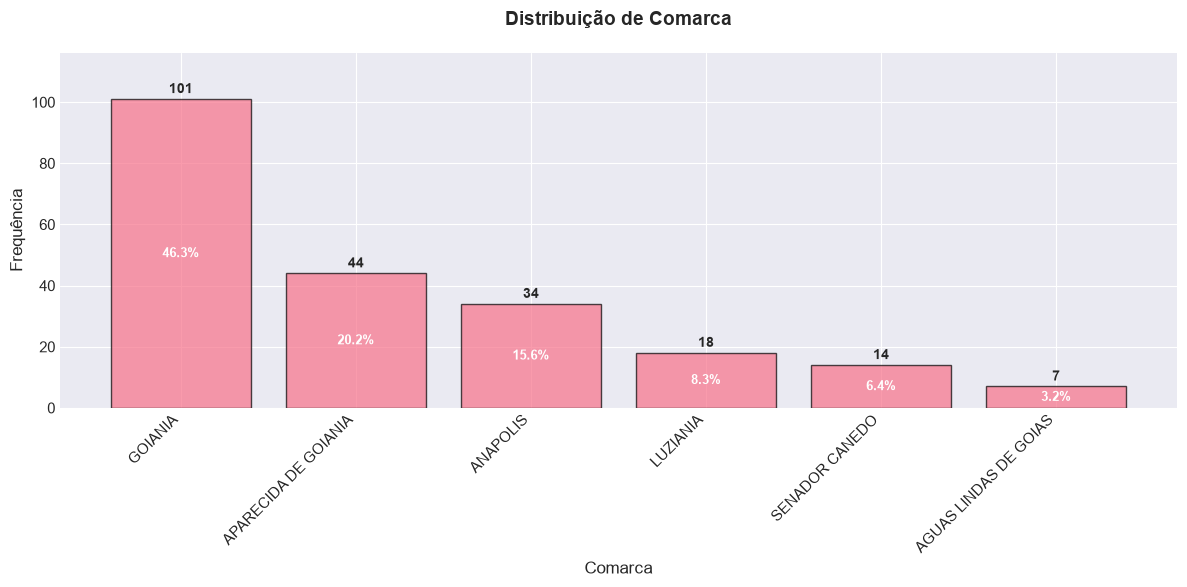


Tabela de Frequências: Comarca

Total de observações: 218



,Categoria,Contagem,Proporção (%)
0,GOIANIA,101,46.33
1,APARECIDA DE GOIANIA,44,20.18
2,ANAPOLIS,34,15.60
3,LUZIANIA,18,8.26
4,SENADOR CANEDO,14,6.42
5,AGUAS LINDAS DE GOIAS,7,3.21


In [35]:
# Exemplo: substitua 'NOME_DA_VARIAVEL' pela primeira variável categórica
# grafico_barras_completo(dados, 'NOME_DA_VARIAVEL')

# SEU CÓDIGO AQUI
grafico_barras_completo(dados, 'Comarca', decresc='sim')

**Desafio:** alterar a função 'grafico_barras_completo' para acrescentar mais um parâmetro: pareto = 'sim' ou 'não' para, quando houver a opção pela ordem decrescente, então tamabém exibir a curva com as frequências relativas acumuladas (num segundo eixo y à direita do gráfico) e a indicação do ponto de corte em 80% da frequência relativa.

---

## 5. Análise de Variáveis Quantitativas

### Objetivo
Criar dot plots, histogramas e boxplots para cada variável quantitativa, sempre indicando a unidade de medida.

In [36]:
# Identificar variáveis quantitativas
vars_quantitativas = dados.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variáveis quantitativas identificadas:")
for i, var in enumerate(vars_quantitativas, 1):
    print(f"{i}. {var}")

Variáveis quantitativas identificadas:
1. N_ordem
2. N_indiciados
3. N_vitimas
4. Tramitacao_direta
5. Arma_de_fogo
6. Validacao
7. Prazo_conclusao_IP
8. Tempo_conclusao_ip
9. Quantidade_manifestacao_ip
10. Tempo_conclusao_mp


### Função auxiliar para análise completa de variável quantitativa

In [43]:
def analise_var_quantitativa(dados, variavel, unidade="", bins=20):
    """
    Cria dot plot, histograma e boxplot para uma variável quantitativa.
    
    Parâmetros:
    - dados: DataFrame
    - variavel: nome da variável quantitativa
    - unidade: unidade de medida (ex: 'dias', 'anos', 'quantidade')
    - bins: número de intervalos para o histograma
    """
    # Remover valores nulos
    serie = dados[variavel].dropna()
    
    # Estatísticas descritivas
    stats_dict = {
        'Média': serie.mean(),
        'Mediana': serie.median(),
        'Desvio Padrão': serie.std(),
        'Mínimo': serie.min(),
        'Q1 (25%)': serie.quantile(0.25),
        'Q3 (75%)': serie.quantile(0.75),
        'Máximo': serie.max(),
        'IQR': serie.quantile(0.75) - serie.quantile(0.25),
        'N (obs.)': len(serie)
    }
    
    # Criar figura com 3 subplots verticalmente (3 x 1)
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    
    # 1. Dot Plot
    axes[0].plot(serie.values, [1]*len(serie), 'o', alpha=0.5, markersize=8)
    axes[0].set_yticks([])
    axes[0].set_xlabel(f'{variavel} ({unidade})' if unidade else variavel, fontsize=11)
    axes[0].set_title('Dot Plot', fontsize=12, fontweight='bold')
    axes[0].spines['left'].set_visible(False)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].grid(axis='x', alpha=0.3)
    
    # 2. Histograma
    axes[1].hist(serie, bins=bins, alpha=0.7, edgecolor='black', color='steelblue')
    axes[1].axvline(serie.mean(), color='red', linestyle='--', linewidth=2, label=f'Média = {serie.mean():.2f}')
    axes[1].axvline(serie.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana = {serie.median():.2f}')
    axes[1].set_xlabel(f'{variavel} ({unidade})' if unidade else variavel, fontsize=11)
    axes[1].set_ylabel('Frequência', fontsize=11)
    axes[1].set_title('Histograma', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    
    # 3. Boxplot
    bp = axes[2].boxplot(serie, vert=False, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=8, alpha=0.5))
    # Adicionar losango vermelho na posição da média
    axes[2].plot(serie.mean(), 1, marker='D', color='red', markersize=10, 
                 markeredgecolor='darkred', markeredgewidth=1.5, zorder=3)
    axes[2].set_xlabel(f'{variavel} ({unidade})' if unidade else variavel, fontsize=11)
    axes[2].set_title('Boxplot', fontsize=12, fontweight='bold')
    axes[2].set_yticklabels([''])
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)
    axes[2].grid(axis='x', alpha=0.3)
    
    plt.suptitle(f'Análise de {variavel}', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Exibir estatísticas
    print(f"\nEstatísticas Descritivas: {variavel}")
    print("=" * 60)
    for key, value in stats_dict.items():
        if key == 'N (obs.)':
            print(f"{key:20s}: {int(value)}")
        else:
            print(f"{key:20s}: {value:.2f} {unidade}")
    print()

### Exercício 2: Análise individual de variáveis quantitativas

**Instruções:**
1. Para cada variável quantitativa, use a função `analise_var_quantitativa()`
2. **IMPORTANTE:** Inclua a unidade de medida apropriada (dias, anos, quantidade, etc.)
3. Observe:
   - A distribuição é simétrica ou assimétrica?
   - Existem outliers?
   - Qual a variabilidade dos dados?
   - A média e mediana são próximas?

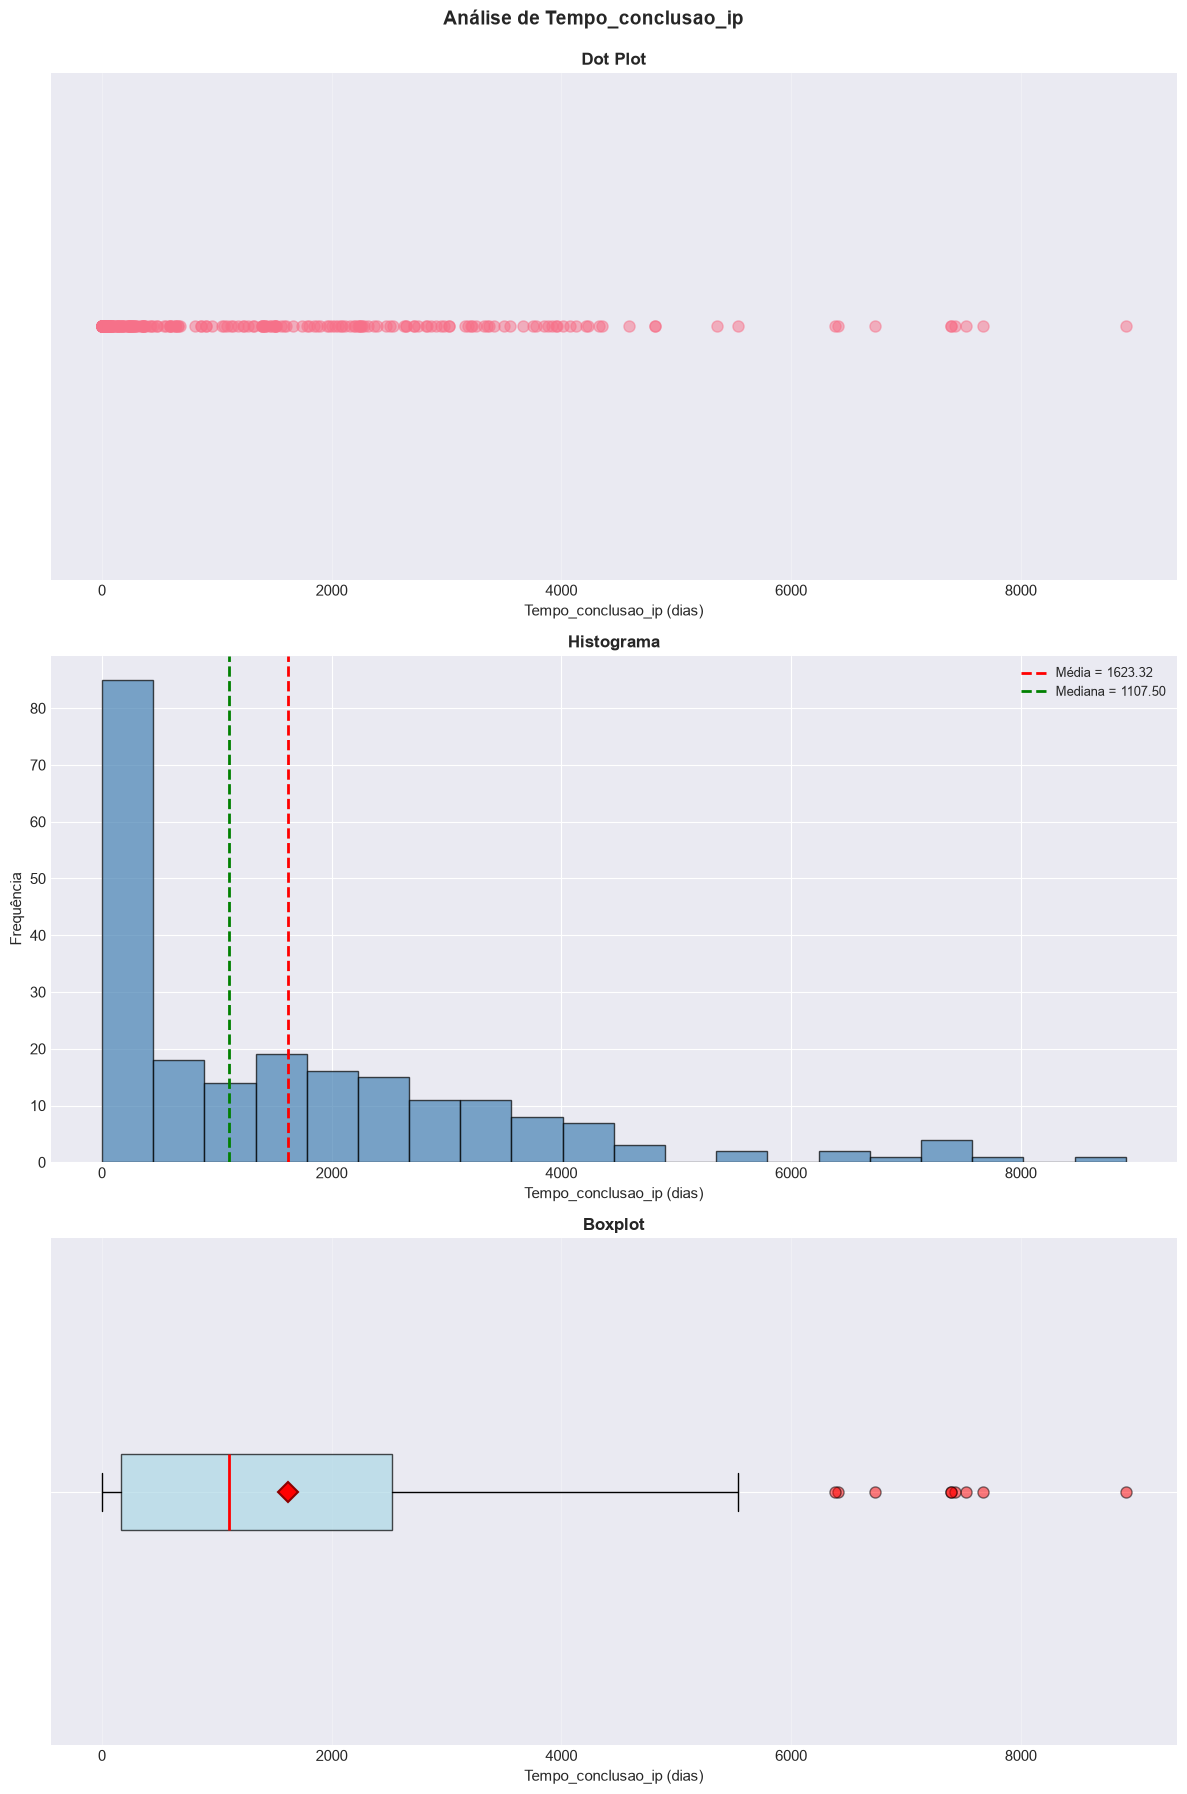


Estatísticas Descritivas: Tempo_conclusao_ip
Média               : 1623.32 dias
Mediana             : 1107.50 dias
Desvio Padrão       : 1815.25 dias
Mínimo              : 0.00 dias
Q1 (25%)            : 167.25 dias
Q3 (75%)            : 2523.75 dias
Máximo              : 8914.00 dias
IQR                 : 2356.50 dias
N (obs.)            : 218



In [44]:
# Exemplo: substitua 'NOME_DA_VARIAVEL' e 'UNIDADE'
# analise_var_quantitativa(dados, 'NOME_DA_VARIAVEL', unidade='dias')

# SEU CÓDIGO AQUI
analise_var_quantitativa(dados, 'Tempo_conclusao_ip', unidade='dias')

---

## 6. Comparação de Variáveis Quantitativas por Grupos

### Objetivo
Criar gráficos lado a lado (dot plots, histogramas e boxplots) comparando a distribuição de variáveis quantitativas entre diferentes grupos categóricos.

### Função para comparação de grupos com boxplots

In [ ]:
def comparacao_grupos_boxplot(dados, var_quantitativa, var_categorica, unidade=""):
    """
    Cria boxplots lado a lado para comparar uma variável quantitativa entre grupos.
    
    Parâmetros:
    - dados: DataFrame
    - var_quantitativa: nome da variável quantitativa
    - var_categorica: nome da variável categórica (grupos)
    - unidade: unidade de medida
    """
    # Preparar dados
    df_temp = dados[[var_quantitativa, var_categorica]].dropna()
    
    # Calcular estatísticas por grupo
    stats_grupos = df_temp.groupby(var_categorica)[var_quantitativa].describe()
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Criar boxplot
    bp = df_temp.boxplot(column=var_quantitativa, by=var_categorica, ax=ax,
                         patch_artist=True, return_type='dict',
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
    
    ax.set_xlabel(var_categorica, fontsize=12)
    ax.set_ylabel(f'{var_quantitativa} ({unidade})' if unidade else var_quantitativa, fontsize=12)
    ax.set_title(f'{var_quantitativa} por {var_categorica}', fontsize=14, fontweight='bold')
    plt.suptitle('')  # Remover título automático do pandas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Exibir estatísticas
    print(f"\nEstatísticas de {var_quantitativa} por {var_categorica}")
    print("=" * 80)
    display(stats_grupos.round(2))
    print()

### Função para comparação de grupos com histogramas sobrepostos

In [ ]:
def comparacao_grupos_histograma(dados, var_quantitativa, var_categorica, unidade="", bins=15):
    """
    Cria histogramas sobrepostos para comparar uma variável quantitativa entre grupos.
    """
    df_temp = dados[[var_quantitativa, var_categorica]].dropna()
    grupos = df_temp[var_categorica].unique()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for grupo in grupos:
        subset = df_temp[df_temp[var_categorica] == grupo][var_quantitativa]
        ax.hist(subset, bins=bins, alpha=0.5, label=str(grupo), edgecolor='black')
    
    ax.set_xlabel(f'{var_quantitativa} ({unidade})' if unidade else var_quantitativa, fontsize=12)
    ax.set_ylabel('Frequência', fontsize=12)
    ax.set_title(f'Distribuição de {var_quantitativa} por {var_categorica}', fontsize=14, fontweight='bold')
    ax.legend(title=var_categorica, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

### Exercício 3: Compare variáveis quantitativas entre grupos

**Instruções:**
1. Identifique combinações interessantes de variáveis quantitativas e categóricas
2. Use as funções `comparacao_grupos_boxplot()` e `comparacao_grupos_histograma()`
3. Analise:
   - Qual grupo tem maior mediana?
   - Qual grupo é mais variável?
   - Existem diferenças notáveis entre os grupos?
   - Algum grupo tem mais outliers?

In [ ]:
# Exemplo:
# comparacao_grupos_boxplot(dados, 'VAR_QUANTITATIVA', 'VAR_CATEGORICA', unidade='dias')
# comparacao_grupos_histograma(dados, 'VAR_QUANTITATIVA', 'VAR_CATEGORICA', unidade='dias')

# SEU CÓDIGO AQUI

---

## 7. Análise de Associações entre Variáveis Categóricas

### Objetivo
Criar gráficos mosaico para explorar associações entre variáveis categóricas e realizar testes de independência.

In [ ]:
# Instalar biblioteca para gráficos mosaico (se necessário)
# !pip install statsmodels

In [ ]:
from statsmodels.graphics.mosaicplot import mosaic
from scipy.stats import chi2_contingency

### Função para gráfico mosaico com teste de associação

In [ ]:
def analise_associacao_categoricas(dados, var1, var2):
    """
    Cria gráfico mosaico e realiza teste qui-quadrado de independência.
    
    Parâmetros:
    - dados: DataFrame
    - var1: primeira variável categórica
    - var2: segunda variável categórica
    """
    # Remover valores nulos
    df_temp = dados[[var1, var2]].dropna()
    
    # Tabela de contingência
    tabela_cont = pd.crosstab(df_temp[var1], df_temp[var2], margins=True)
    
    # Tabela de proporções
    tabela_prop = pd.crosstab(df_temp[var1], df_temp[var2], normalize='all') * 100
    
    # Teste qui-quadrado
    chi2, p_valor, gl, freq_esperada = chi2_contingency(pd.crosstab(df_temp[var1], df_temp[var2]))
    
    # Criar gráfico mosaico
    fig, ax = plt.subplots(figsize=(12, 8))
    
    mosaic_data = df_temp.groupby([var1, var2]).size()
    mosaic(mosaic_data, ax=ax, title=f'Gráfico Mosaico: {var1} vs {var2}',
           labelizer=lambda k: f'{k[0]}\n{k[1]}',
           properties=lambda key: {'color': plt.cm.Set3(hash(key) % 12)})
    
    plt.tight_layout()
    plt.show()
    
    # Exibir resultados
    print(f"\nTabela de Contingência: {var1} × {var2}")
    print("=" * 80)
    display(tabela_cont)
    
    print(f"\nTabela de Proporções (%)")
    print("=" * 80)
    display(tabela_prop.round(2))
    
    print(f"\nTeste Qui-Quadrado de Independência")
    print("=" * 80)
    print(f"Estatística χ² = {chi2:.4f}")
    print(f"Graus de liberdade = {gl}")
    print(f"p-valor = {p_valor:.4f}")
    
    if p_valor < 0.05:
        print("\n→ Conclusão: Existe evidência de associação significativa entre as variáveis (p < 0.05)")
    else:
        print("\n→ Conclusão: Não há evidência de associação significativa entre as variáveis (p ≥ 0.05)")
    print()

### Exercício 4: Explore associações entre variáveis categóricas

**Instruções:**
1. Identifique pares de variáveis categóricas que possam estar relacionadas
2. Use a função `analise_associacao_categoricas()`
3. Interprete:
   - O gráfico mosaico mostra padrões diferentes do esperado?
   - O teste qui-quadrado indica associação significativa?
   - Quais categorias se destacam na associação?

In [ ]:
# Exemplo:
# analise_associacao_categoricas(dados, 'VARIAVEL_CATEGORICA_1', 'VARIAVEL_CATEGORICA_2')

# SEU CÓDIGO AQUI

---

## 8. Análise de Relações entre Variáveis Quantitativas

### Objetivo
Criar diagramas de dispersão com retas de regressão para explorar relações lineares entre variáveis quantitativas.

### Função para diagrama de dispersão com análise de correlação

In [ ]:
def analise_correlacao(dados, var_x, var_y, unidade_x="", unidade_y=""):
    """
    Cria diagrama de dispersão com reta de regressão e análise de correlação.
    
    Parâmetros:
    - dados: DataFrame
    - var_x: variável para o eixo X
    - var_y: variável para o eixo Y
    - unidade_x: unidade de medida de X
    - unidade_y: unidade de medida de Y
    """
    # Remover valores nulos
    df_temp = dados[[var_x, var_y]].dropna()
    
    # Calcular correlação
    correlacao_pearson = df_temp[var_x].corr(df_temp[var_y])
    correlacao_spearman = df_temp[var_x].corr(df_temp[var_y], method='spearman')
    
    # Regressão linear
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_temp[var_x], df_temp[var_y])
    linha_regressao = slope * df_temp[var_x] + intercept
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Scatter plot
    ax.scatter(df_temp[var_x], df_temp[var_y], alpha=0.6, s=80, edgecolors='black', linewidths=0.5)
    
    # Reta de regressão
    ax.plot(df_temp[var_x], linha_regressao, 'r-', linewidth=2, 
            label=f'Regressão: y = {slope:.3f}x + {intercept:.3f}')
    
    # Configurações
    ax.set_xlabel(f'{var_x} ({unidade_x})' if unidade_x else var_x, fontsize=12)
    ax.set_ylabel(f'{var_y} ({unidade_y})' if unidade_y else var_y, fontsize=12)
    ax.set_title(f'Relação entre {var_x} e {var_y}', fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3)
    
    # Adicionar informações de correlação
    texto_info = f"r de Pearson = {correlacao_pearson:.3f}\n"
    texto_info += f"r de Spearman = {correlacao_spearman:.3f}\n"
    texto_info += f"R² = {r_value**2:.3f}\n"
    texto_info += f"p-valor = {p_value:.4f}"
    
    ax.text(0.05, 0.95, texto_info, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Interpretação
    print(f"\nAnálise de Correlação: {var_x} × {var_y}")
    print("=" * 80)
    print(f"Correlação de Pearson (r):     {correlacao_pearson:.4f}")
    print(f"Correlação de Spearman (ρ):    {correlacao_spearman:.4f}")
    print(f"Coeficiente de determinação (R²): {r_value**2:.4f}")
    print(f"p-valor:                       {p_value:.4f}")
    print(f"\nEquação da reta: {var_y} = {slope:.3f} × {var_x} + {intercept:.3f}")
    
    # Interpretação da força da correlação
    abs_corr = abs(correlacao_pearson)
    if abs_corr < 0.3:
        forca = "fraca"
    elif abs_corr < 0.7:
        forca = "moderada"
    else:
        forca = "forte"
    
    direcao = "positiva" if correlacao_pearson > 0 else "negativa"
    
    print(f"\n→ Interpretação: Correlação linear {forca} e {direcao}")
    
    if p_value < 0.05:
        print(f"→ A correlação é estatisticamente significativa (p < 0.05)")
    else:
        print(f"→ A correlação não é estatisticamente significativa (p ≥ 0.05)")
    
    print(f"→ R² indica que {r_value**2*100:.1f}% da variação em {var_y} é explicada por {var_x}\n")

### Matriz de correlação para visão geral

In [ ]:
def matriz_correlacao(dados, variaveis=None):
    """
    Cria uma matriz de correlação visual (heatmap).
    
    Parâmetros:
    - dados: DataFrame
    - variaveis: lista de variáveis a incluir (se None, usa todas as quantitativas)
    """
    if variaveis is None:
        df_corr = dados.select_dtypes(include=['int64', 'float64'])
    else:
        df_corr = dados[variaveis]
    
    # Calcular matriz de correlação
    corr_matrix = df_corr.corr()
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                fmt='.2f', vmin=-1, vmax=1, ax=ax)
    
    ax.set_title('Matriz de Correlação (Pearson)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\nMatriz de Correlação")
    print("=" * 80)
    display(corr_matrix.round(3))
    
    # Identificar correlações fortes
    print("\nCorrelações mais fortes (|r| > 0.5, excluindo diagonal):")
    print("=" * 80)
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                print(f"{corr_matrix.columns[i]} × {corr_matrix.columns[j]}: r = {corr_matrix.iloc[i, j]:.3f}")
    print()

### Exercício 5: Explore relações entre variáveis quantitativas

**Instruções:**
1. Primeiro, crie a matriz de correlação para ter uma visão geral
2. Identifique pares de variáveis com correlações interessantes
3. Para cada par relevante, use a função `analise_correlacao()`
4. Analise:
   - A relação é linear?
   - É positiva ou negativa?
   - Qual a força da correlação?
   - Existem outliers que influenciam a relação?
   - A relação faz sentido teoricamente?

In [ ]:
# Primeiro, visualize a matriz de correlação
# matriz_correlacao(dados)

# SEU CÓDIGO AQUI

In [ ]:
# Depois, analise pares específicos
# Exemplo:
# analise_correlacao(dados, 'VAR_X', 'VAR_Y', unidade_x='dias', unidade_y='quantidade')

# SEU CÓDIGO AQUI

---

## 9. Síntese e Conclusões

### Exercício Final: Reporte Analítico

Com base em todas as análises realizadas, responda às seguintes questões:

**1. Perfil dos Inquéritos Policiais**

- Quais são as características mais comuns dos inquéritos analisados?
- Existem padrões claros em relação às comarcas ou outros fatores categóricos?

*Sua resposta aqui:*


**2. Variabilidade e Outliers**

- Quais variáveis quantitativas apresentam maior variabilidade?
- Foram identificados outliers? Como eles podem ser explicados?

*Sua resposta aqui:*


**3. Diferenças entre Grupos**

- Existem diferenças importantes nas variáveis quantitativas quando comparamos diferentes grupos categóricos?
- Quais comparações foram mais reveladoras?

*Sua resposta aqui:*


**4. Associações entre Variáveis**

- Quais variáveis categóricas mostraram associação significativa?
- Quais variáveis quantitativas apresentaram correlação forte?
- As associações encontradas fazem sentido do ponto de vista teórico?

*Sua resposta aqui:*


**5. Aprendizados sobre Visualização de Dados**

- Qual tipo de gráfico você achou mais útil para entender os dados? Por quê?
- Houve alguma descoberta surpreendente ao visualizar os dados?

*Sua resposta aqui:*


---

## Referências e Recursos Adicionais

### Bibliotecas Python Utilizadas
- **pandas:** Manipulação e análise de dados
- **matplotlib:** Criação de gráficos
- **seaborn:** Visualizações estatísticas
- **scipy.stats:** Testes estatísticos
- **statsmodels:** Modelos estatísticos e gráficos mosaico

### Para Aprender Mais
- [Documentação do Matplotlib](https://matplotlib.org/)
- [Documentação do Seaborn](https://seaborn.pydata.org/)
- [Documentação do Pandas](https://pandas.pydata.org/)
- [Statsmodels Documentation](https://www.statsmodels.org/)

### Conceitos Estatísticos
- Medidas de tendência central e dispersão
- Correlação vs. Causalidade
- Teste Qui-quadrado de independência
- Regressão linear simples
- Interpretação de boxplots e detecção de outliers

---

## Notas Finais

Este notebook apresentou técnicas fundamentais de análise exploratória de dados. Lembre-se:

1. **Sempre visualize antes de modelar** - gráficos revelam padrões que estatísticas resumidas podem esconder
2. **Contexto é essencial** - números e gráficos só fazem sentido quando interpretados no contexto do problema
3. **Correlação ≠ Causalidade** - uma relação estatística não implica necessariamente causa e efeito
4. **Outliers merecem atenção** - podem ser erros, casos especiais ou os dados mais interessantes
5. **Comunique claramente** - bons gráficos contam uma história que qualquer pessoa pode entender

Bom trabalho! 📊📈